Estimacion CO-VARIABLES CON REDES

Este Jupyter será utilizado unicamente para la creación de la base de datos a utilizar.

Predicciones para temperaturas y anomalía climática

Columnas detectadas:
Anomalía: ANOM
Temp mínima: Temperaturaminimapromedio
Temp máxima: TemperaturaMaximapromedioanual

Periodo histórico usado para anomalía: 19842024

Anomalía (ANOM) → RMSE: 0.580, MAPE: 0.49%


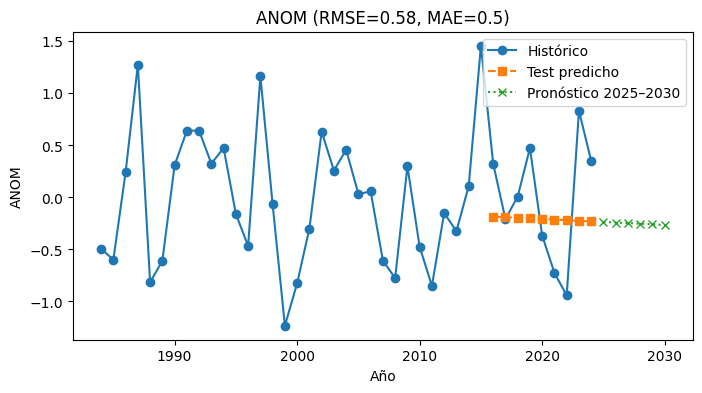


Temperaturaminimapromedio → RMSE: 0.887, MAE: 0.69


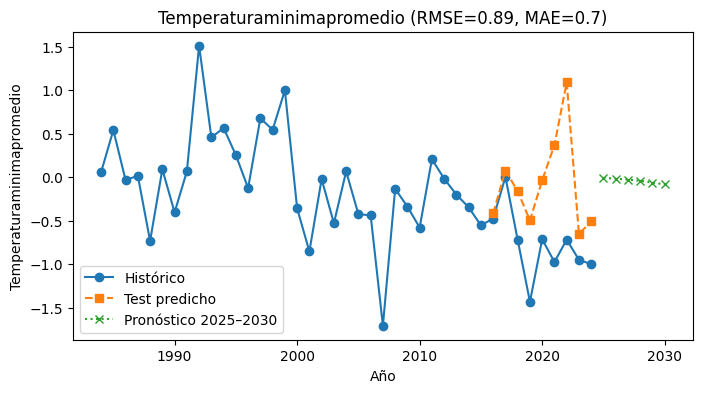


TemperaturaMaximapromedioanual → RMSE: 1.198, MAE: 1.00


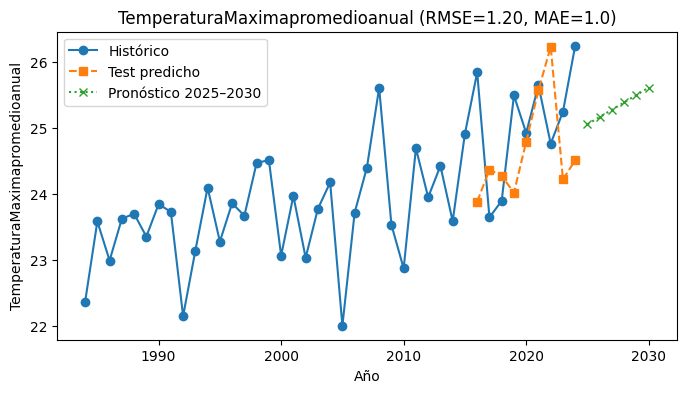


Pronósticos 2025–2030:
 Año  Anomalia  Temperaturaminimapromedio  TemperaturaMaximapromedioanual
2025    -0.236                      -0.45                           25.33
2026    -0.241                      -0.52                           25.44
2027    -0.246                      -0.58                           25.54
2028    -0.252                      -0.65                           25.64
2029    -0.259                      -0.71                           25.75
2030    -0.265                      -0.77                           25.85


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt

# 1) Carga y limpieza de datos
df = pd.read_excel("Datos_Lagos.xlsx", sheet_name="DATOS LAGO CABURGUA")
df.columns = [
    col.strip()
       .replace(" ", "_")
       .replace("á", "a")
       .replace("é", "e")
       .replace("í", "i")
       .replace("ó", "o")
       .replace("ú", "u")
    for col in df.columns
]
df["Año"] = pd.to_datetime(df["Año"], errors="coerce").dt.year
df = df[df["Año"].notna()].copy()
df = df.set_index("Año")
df.index = df.index.astype(int)

# 2) Detectar columnas relevantes
anom_cols = [c for c in df.columns if "anom" in c.lower()]
if not anom_cols:
    raise ValueError("No encontré columna de anomalía.")
anom_col = anom_cols[0]

tmin_cols = [c for c in df.columns if "temp" in c.lower() and "min" in c.lower()]
tmin_col = tmin_cols[0] if tmin_cols else None

tmax_cols = [c for c in df.columns if "temp" in c.lower() and "max" in c.lower()]
tmax_col = tmax_cols[0] if tmax_cols else None

print("Columnas detectadas:")
print("Anomalía:", anom_col)
print("Temp mínima:", tmin_col)
print("Temp máxima:", tmax_col)

# 3) Definir periodo histórico (sin NaN en anomalía)
mask_h = df[anom_col].notnull()
years_hist = df.index.values[mask_h]
min_year, max_year = years_hist.min(), years_hist.max()
print(f"\nPeriodo histórico usado para anomalía: {min_year}{max_year}")

# 4) Normalizar año según periodo histórico
df['Year_norm'] = (df.index - min_year) / (max_year - min_year)

# 5) Modelo univariante para anomalía
X_anom = df.loc[years_hist, ['Year_norm']].values
y_anom = df.loc[years_hist, anom_col].values

X_tr_a, X_te_a, y_tr_a, y_te_a = train_test_split(X_anom, y_anom, test_size=0.2, shuffle=False)
model_anom = MLPRegressor(hidden_layer_sizes=(64,32), activation='relu', solver='adam',
                          max_iter=2000, random_state=0)
model_anom.fit(X_tr_a, y_tr_a)

y_pred_a = model_anom.predict(X_te_a)
rmse_a = np.sqrt(mean_squared_error(y_te_a, y_pred_a))
mae_val  = mean_absolute_error(y_te_a, y_pred_a)
print(f"\nAnomalía ({anom_col}) → RMSE: {rmse_a:.3f}, MAPE: {mae_val:.2f}%")

# Pronóstico anomalía 2025–2030
years_fut = np.arange(max_year+1, 2031)
years_fut_norm = (years_fut - min_year) / (max_year - min_year)
X_fut_a = years_fut_norm.reshape(-1, 1)
y_fut_a = model_anom.predict(X_fut_a)

plt.figure(figsize=(8,4))
plt.plot(years_hist, y_anom, 'o-', label='Histórico')
plt.plot(years_hist[-len(y_te_a):], y_pred_a, 's--', label='Test predicho')
plt.plot(years_fut, y_fut_a, 'x:', label='Pronóstico 2025–2030')
plt.title(f"{anom_col} (RMSE={rmse_a:.2f}, MAE={mae_val:.1f})")
plt.xlabel("Año")
plt.ylabel(anom_col)
plt.legend()
plt.show()

# 6) Función para modelos multivariantes
def forecast_and_plot(target_col):
    # filas sin NaN en Year_norm, anomalía y target
    mask = df[['Year_norm', anom_col, target_col]].notnull().all(axis=1)
    years_c = df.index.values[mask]
    X = df.loc[mask, ['Year_norm', anom_col]].values
    y = df.loc[mask, target_col].values

    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, shuffle=False)
    model = MLPRegressor(hidden_layer_sizes=(64,32), activation='relu', solver='adam',
                         max_iter=2000, random_state=0)
    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae = mean_absolute_error(y_te, y_pred)
    print(f"\n{target_col} → RMSE: {rmse:.3f}, MAE: {mae:.2f}")

    y_fut = model.predict(np.column_stack((years_fut_norm, y_fut_a)))
    plt.figure(figsize=(8,4))
    plt.plot(years_c, y, 'o-', label='Histórico')
    plt.plot(years_c[-len(y_te):], y_pred, 's--', label='Test predicho')
    plt.plot(years_fut, y_fut, 'x:', label='Pronóstico 2025–2030')
    plt.title(f"{target_col} (RMSE={rmse:.2f}, MAE={mae:.1f})")
    plt.xlabel("Año")
    plt.ylabel(target_col)
    plt.legend()
    plt.show()

# 7) Ejecutar para cada target
for col in [tmin_col, tmax_col]:
    if col:
        forecast_and_plot(col)
    else:
        print(f"\nOmitido: no hay columna para {col}")

        # Crear DataFrame de resultados
df_predicciones = pd.DataFrame({
    "Año": years_fut,
    "Anomalia": np.round(y_fut_a, 3)
})

# Predecir y agregar Temp Mínima y Temp Máxima si existen
for col in [tmin_col, tmax_col]:
    if col:
        # Entrenar modelo
        mask = df[['Year_norm', anom_col, col]].notnull().all(axis=1)
        X = df.loc[mask, ['Year_norm', anom_col]].values
        y = df.loc[mask, col].values
        model = MLPRegressor(hidden_layer_sizes=(64,32), max_iter=2000, random_state=0)
        model.fit(X, y)
        # Predecir valores futuros
        y_fut = model.predict(np.column_stack((years_fut_norm, y_fut_a)))
        df_predicciones[col] = np.round(y_fut, 2)

# Mostrar tabla final
print("\nPronósticos 2025–2030:")
print(df_predicciones.to_string(index=False))


Predicción para precipitaciones

Usando columnas:
 • Anomalía       -> ANOM
 • Precipitaciones -> Precipitacionesanuales
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step

LSTM Precipitaciones → RMSE: 0.079, MAPE: 0.06%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step


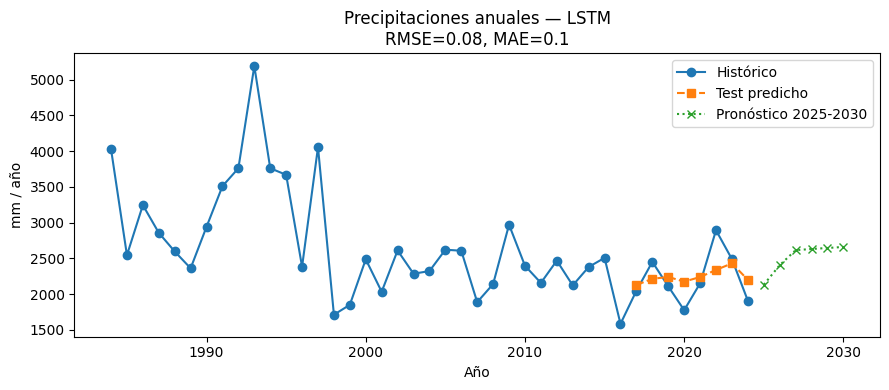


Pronóstico 2025-2030:
 Año  Precipitaciones_pronosticadas
2025                    2131.850098
2026                    2405.290039
2027                    2614.830078
2028                    2631.479980
2029                    2645.580078
2030                    2660.020020


In [ ]:
# ============================================================
# Pronóstico de Precipitaciones anuales hasta 2030 con LSTM
# (usando Anomalía pronosticada con un MLP)
# ============================================================
# 1) Imports
# ------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.neural_network import MLPRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import unicodedata, warnings
warnings.filterwarnings("ignore")

# 2) Carga y limpieza de datos
# ------------------------------------------------------------
df = pd.read_excel("Datos_Lagos.xlsx", sheet_name="DATOS LAGO CABURGUA")

# — limpiar nombres de columnas (acentos, espacios) —
df.columns = [
    unicodedata.normalize("NFKD", c).encode("ascii", "ignore").decode()
      .strip().replace(" ", "_")
    for c in df.columns
]

# --- detectar la columna de año ---------------------------------
possible_year_cols = [c for c in df.columns if c.lower() in {"ano", "anio", "year"}]
if not possible_year_cols:
    raise ValueError("No encontré columna de año (Año/Ano/Year) tras la limpieza.")
year_col = possible_year_cols[0]               # tomamos la primera coincidencia

# --- convertir a entero y fijar como índice ----------------------
df[year_col] = pd.to_datetime(df[year_col], errors="coerce").dt.year
df = df[df[year_col].notna()].copy()
df = df.set_index(year_col)
df = df.select_dtypes(include=[np.number])      # todo numérico
df.index = df.index.astype(int)

# 3) Detectar nombres de columnas clave
# ------------------------------------------------------------
anom_col = [c for c in df.columns if "anom" in c.lower()][0]               # p.ej. 'ANOM'
prec_col = [c for c in df.columns if "precipitac" in c.lower()][0]        # p.ej. 'Precipitacionesanuales'

print("Usando columnas:")
print(" • Anomalía       ->", anom_col)
print(" • Precipitaciones ->", prec_col)

# 4) Normalizar el año
# ------------------------------------------------------------
min_year, max_year = df.index.min(), df.index.max()
df["Year_norm"] = (df.index - min_year) / (max_year - min_year)

# 5) Crear DataFrame sin NaN (o interpolar si prefieres)
# ------------------------------------------------------------
vars_needed = ["Year_norm", anom_col, prec_col]
df_lstm = df[vars_needed].dropna().copy()

# 6) Escalar features (Year_norm + ANOM) y target (Precipitaciones)
# ------------------------------------------------------------
feat  = df_lstm[["Year_norm", anom_col]].values
prec  = df_lstm[[prec_col]].values

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
feat_s  = scaler_X.fit_transform(feat)
prec_s  = scaler_y.fit_transform(prec)

# 7) Función para crear secuencias de longitud n_steps
# ------------------------------------------------------------
def make_sequences(X, y, n_steps):
    Xs, ys = [], []
    for i in range(len(X) - n_steps):
        block_X = X[i : i + n_steps]
        block_y = y[i + n_steps]
        if np.isnan(block_X).any() or np.isnan(block_y):
            continue
        Xs.append(block_X)
        ys.append(block_y)
    return np.array(Xs), np.array(ys)

n_steps = 3
X_seq, y_seq = make_sequences(feat_s, prec_s, n_steps)

# 8) Split temporal 80 % / 20 %
# ------------------------------------------------------------
cut = int(len(X_seq) * 0.8)
X_tr, X_te = X_seq[:cut], X_seq[cut:]
y_tr, y_te = y_seq[:cut], y_seq[cut:]

# 9) Entrenar modelo LSTM para Precipitaciones
# ------------------------------------------------------------
model = Sequential([
    LSTM(64, activation="tanh", input_shape=(n_steps, 2)),
    Dense(32, activation="relu"),
    Dense(1)
])
model.compile(optimizer="adam", loss="mse")
model.fit(X_tr, y_tr, epochs=200, batch_size=8,
          validation_split=0.1, verbose=0)

# 10) Evaluación sobre el bloque test
# ------------------------------------------------------------
y_pred_te = model.predict(X_te)
rmse  = np.sqrt(mean_squared_error(y_te, y_pred_te))
mae_val  = mean_absolute_error(y_te, y_pred_te)
print(f"\nLSTM Precipitaciones → RMSE: {rmse:.3f}, MAPE: {mae_val:.2f}%")

# 11) Modelo de Anomalía (MLP) para predecir ANOM 2025-2030
# ------------------------------------------------------------
X_anom = df_lstm[["Year_norm"]].values
y_anom = df_lstm[[anom_col]].values
X_tr_a, X_te_a, y_tr_a, y_te_a = train_test_split(
    X_anom, y_anom, test_size=0.2, shuffle=False
)
mlp_anom = MLPRegressor(hidden_layer_sizes=(64,32),
                        max_iter=2000, random_state=0)
mlp_anom.fit(X_tr_a, y_tr_a.ravel())

# 12) Preparar features futuros (2025-2030)
# ------------------------------------------------------------
years_fut      = np.arange(max_year -5, 2031)               # [2025…2030]
years_fut_norm = (years_fut - min_year) / (max_year - min_year)
y_fut_anom     = mlp_anom.predict(years_fut_norm.reshape(-1,1))

# 13) Combinar histórico + futuro y generar secuencias de pronóstico
# ------------------------------------------------------------
feat_future = np.column_stack([years_fut_norm, y_fut_anom])
feat_all    = np.vstack([feat_s, feat_future])

def make_seq_only_X(X, n_steps):
    Xs = []
    for i in range(len(X) - n_steps):
        blk = X[i : i + n_steps]
        if np.isnan(blk).any():
            continue
        Xs.append(blk)
    return np.array(Xs)

X_all      = make_seq_only_X(feat_all, n_steps)
X_forecast = X_all[-len(years_fut):]                          # 6 secuencias

# 14) Pronosticar Precipitaciones 2025-2030 y des-escalar
# ------------------------------------------------------------
y_fut_s = model.predict(X_forecast)
y_fut   = scaler_y.inverse_transform(y_fut_s).flatten()

# 15) Graficar histórico, test y pronóstico futuro
# ------------------------------------------------------------
plt.figure(figsize=(9,4))
plt.plot(df_lstm.index, df_lstm[prec_col], 'o-', label='Histórico')
yrs_te = df_lstm.index[n_steps + cut : n_steps + cut + len(y_te)]
plt.plot(yrs_te,
         scaler_y.inverse_transform(y_pred_te), 's--', label='Test predicho')
plt.plot(years_fut, y_fut, 'x:', label='Pronóstico 2025-2030')
plt.title(f"Precipitaciones anuales — LSTM\nRMSE={rmse:.2f}, MAE={mae_val:.1f}")
plt.xlabel("Año")
plt.ylabel("mm / año")
plt.legend()
plt.tight_layout()
plt.show()

# 16) Imprimir (y/o guardar) tabla de pronóstico
# ------------------------------------------------------------
df_forecast = pd.DataFrame({
    "Año": years_fut,
    "Precipitaciones_pronosticadas": np.round(y_fut, 2)
})
print("\nPronóstico 2025-2030:")
print(df_forecast.to_string(index=False))




Guardar en .XLSX

In [ ]:
years_total = np.arange(1984, 2031)
df_final = pd.DataFrame({"Año": years_total})
# Asegura que predicciones tengan índice tipo int
y_fut = pd.Series(data=np.round(y_fut, 2), index=years_fut.astype(int))

if tmin_col:
    tmin_pred = df_predicciones.set_index("Año")[tmin_col].round(2)
if tmax_col:
    tmax_pred = df_predicciones.set_index("Año")[tmax_col].round(2)

# --------------------------
# PREPARAR LAS VARIABLES
# --------------------------
# 1. Superficie Aproximada
col_sup = [c for c in df.columns if "superficie" in c.lower()][0]
df_final["Superficie_Aproximada"] = df[col_sup].reindex(years_total).values

# 2. Precipitaciones
col_prec = [c for c in df.columns if "precipitacion" in c.lower()][0]
prec_hist = df[col_prec].reindex(years_total)
prec_full = prec_hist.copy()
prec_full.loc[y_fut.index] = y_fut
df_final["Precipitaciones_Anuales"] = prec_full.values

# 3. Temperatura Mínima
if tmin_col:
    tmin_hist = df[tmin_col].reindex(years_total)
    tmin_full = tmin_hist.copy()
    tmin_full.loc[tmin_pred.index] = tmin_pred
    df_final["Temperatura_Minima_Media"] = tmin_full.values

# 4. Temperatura Máxima
if tmax_col:
    tmax_hist = df[tmax_col].reindex(years_total)
    tmax_full = tmax_hist.copy()
    tmax_full.loc[tmax_pred.index] = tmax_pred
    df_final["Temperatura_Maxima_Media"] = tmax_full.values

# 5. Presencia Dique
df_final["Presencia_Dique"] = df_final["Año"].apply(lambda x: 1 if 2008 <= x <= 2022 else 0)

print("\nVerificación rápida:")
print(df_final.tail(10))

# --------------------------
# EXPORTAR A EXCEL
# --------------------------
df_final.to_excel("Base_Lago_Caburgua.xlsx", index=False)
print("\n✅ Archivo corregido exportado: Base_Completa_1984_2030.xlsx")



Verificación rápida:
     Año  Superficie_Aproximada  Precipitaciones_Anuales  \
37  2021                  50.22              2150.600000   
38  2022                  50.02              2893.700000   
39  2023                    NaN              2489.900000   
40  2024                    NaN              1908.100000   
41  2025                    NaN              2014.449951   
42  2026                    NaN              2187.370117   
43  2027                    NaN              2320.429932   
44  2028                    NaN              2383.080078   
45  2029                    NaN              2384.580078   
46  2030                    NaN              2385.790039   

    Temperatura_Minima_Media  Temperatura_Maxima_Media  Presencia_Dique  
37                    -0.975                    25.650                1  
38                    -0.718                    24.766                1  
39                    -0.950                    25.250                0  
40                   